## Imports & Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

from app.models.transformer import BehavioralTransformer, TransformerConfig
from app.models.gan_autoencoder import GANAutoencoderKYC
from app.models.ensemble import ModelEnsemble
from synthetic_data_generator.behavioral import (
    UserProfileGenerator, TransactionSequenceGenerator, AnomalyInjector
)
from synthetic_data_generator.kyc import DocumentMetadataGenerator, ForgerySimulator

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Training on: {DEVICE}")


Training on: cpu


## Train Behavioral Transformer

Training on: cpu
Dataset: 18,237 sequences | Fraud: 373 (2.05%) | Legit: 17864
(18,237 with sliing windows)
Train: 14,589 | Val: 3,648
Train fraud rate: 2.04% | Val fraud rate: 2.06%
Using Focal Loss — alpha=0.75, gamma=2.0
Fraud rate: 2.05% 

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val AUC |       LR
------------------------------------------------------------------------------
     1 |     0.0730 |     0.504 |   0.0822 |   0.021 |  0.5038 | 0.000080
     5 |     0.0379 |     0.837 |   0.0283 |   0.864 |  0.8687 | 0.000200
    10 |     0.0154 |     0.938 |   0.0265 |   0.879 |  0.9201 | 0.000196
    15 |     0.0082 |     0.972 |   0.0173 |   0.964 |  0.9081 | 0.000184
    20 |     0.0055 |     0.981 |   0.0166 |   0.955 |  0.9159 | 0.000165
    25 |     0.0041 |     0.986 |   0.0219 |   0.948 |  0.9125 | 0.000142

  Early stopping at epoch 27 — no AUC improvement for 15 epochs.

  Best Val AUC: 0.9274
  Optimal threshold: 0.88  (F1 = 0.5455 vs 0.3956 at 0.50)

  Classif

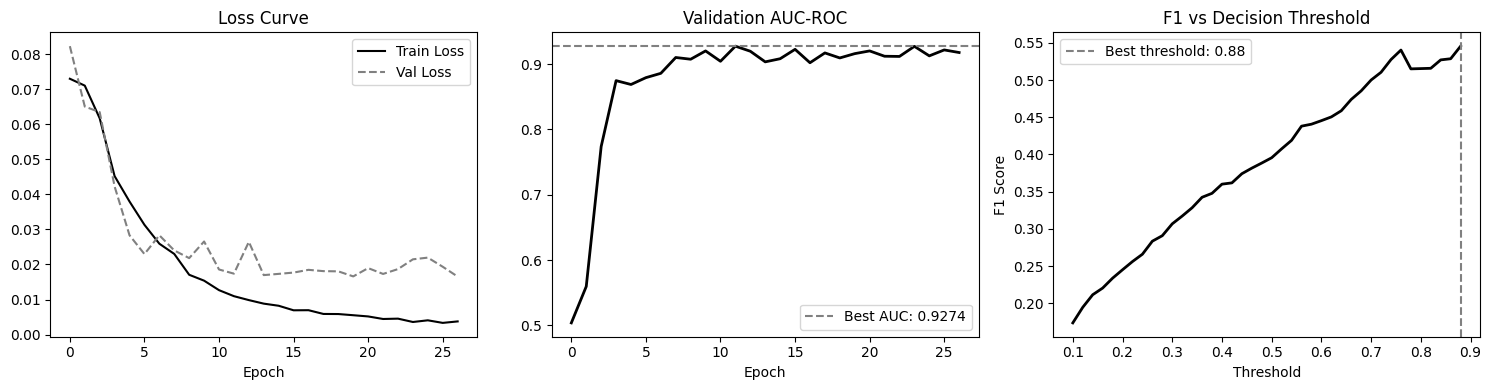


  Checkpoint saved → ../checkpoints/transformer.pt
  Use threshold 0.88 at inference time for best F1.


In [10]:
# Cell — Behavioral Transformer Training
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, WeightedRandomSampler
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, roc_auc_score, f1_score

from app.models.transformer import BehavioralTransformer, TransformerConfig

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Training on: {DEVICE}")

# ── Step 1: Rebuild dataset using SLIDING WINDOWS ─────────────
import json
import numpy as np
from collections import defaultdict
from app.services.sequential_service import _transaction_to_vector

SEQ_LEN     = 50
FEATURE_DIM = 32
STRIDE      = 5        # Step size between windows — smaller = more samples

with open("../synthetic_data_generator/outputs/behavioral/transactions.json") as f:
    txns_raw = json.load(f)

# Group and sort transactions per user
user_txns = defaultdict(list)
for t in txns_raw:
    user_txns[t["user_id"]].append(t)

sequences, labels = [], []

for uid, txns in user_txns.items():
    txns_sorted = sorted(txns, key=lambda x: x.get("created_at", ""))

    if len(txns_sorted) < 10:
        continue   # skip users with too few transactions

    # Encode all transactions for this user upfront
    all_vecs = [_transaction_to_vector(t) for t in txns_sorted]

    for end in range(SEQ_LEN, len(all_vecs) + 1, STRIDE):
        start       = end - SEQ_LEN
        window      = all_vecs[start:end]
        window_txns = txns_sorted[start:end]

        while len(window) < SEQ_LEN:
            window.insert(0, np.zeros(FEATURE_DIM, dtype=np.float32))

        recent_txns = window_txns[-15:]
        label       = int(any(t.get("label", 0) == 1 for t in recent_txns))

        sequences.append(np.stack(window[-SEQ_LEN:], axis=0))
        labels.append(label)

X = torch.tensor(np.array(sequences), dtype=torch.float32)
y = torch.tensor(labels,              dtype=torch.float32).unsqueeze(1)

fraud_count = y.sum().item()
legit_count = len(y) - fraud_count
fraud_rate  = fraud_count / len(y)

print(f"Dataset: {len(X):,} sequences | "
      f"Fraud: {fraud_count:.0f} ({fraud_rate:.2%}) | "
      f"Legit: {legit_count:.0f}")
print(f"({len(X):,} with sliing windows)")

# ── Step 2: Stratified train/val split ────────────────────────
fraud_idx = [i for i, l in enumerate(labels) if l == 1]
legit_idx = [i for i, l in enumerate(labels) if l == 0]

np.random.seed(42)
np.random.shuffle(fraud_idx)
np.random.shuffle(legit_idx)

n_fraud_train = int(0.8 * len(fraud_idx))
n_legit_train = int(0.8 * len(legit_idx))

train_idx = fraud_idx[:n_fraud_train] + legit_idx[:n_legit_train]
val_idx   = fraud_idx[n_fraud_train:] + legit_idx[n_legit_train:]

np.random.shuffle(train_idx)
np.random.shuffle(val_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,}")
print(f"Train fraud rate: {y_train.mean():.2%} | Val fraud rate: {y_val.mean():.2%}")

# ── Step 3: Weighted sampler — oversample fraud in every batch ─
train_labels_list = y_train.squeeze().tolist()
class_counts      = [train_labels_list.count(0), train_labels_list.count(1)]
class_weights     = [1.0 / c for c in class_counts]
sample_weights    = [class_weights[int(l)] for l in train_labels_list]
sampler           = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(sample_weights),
    replacement = True,
)

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)

# Use sampler instead of shuffle=True — sampler handles distribution
train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

# ── Step 4: Model with stronger config ────────────────────────
config = TransformerConfig(
    input_dim       = FEATURE_DIM,
    d_model         = 128,
    nhead           = 4,
    num_layers      = 3,
    dim_feedforward = 256,
    dropout         = 0.2,
    max_seq_len     = SEQ_LEN,
)
model = BehavioralTransformer(config).to(DEVICE)

# ── Step 5: Loss with correct pos_weight ──────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        probs       = torch.sigmoid(logits)
        p_t         = probs * targets + (1 - probs) * (1 - targets)
        alpha_t     = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss  = alpha_t * (1 - p_t) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=0.75, gamma=2.0)
print(f"Using Focal Loss — alpha=0.75, gamma=2.0")
print(f"Fraud rate: {fraud_rate:.2%} ")

# ── Step 6: Update model classifier to output logits ──────────
import torch.nn as nn

class BehavioralTransformerLogits(nn.Module):
    """
    Wrapper that returns raw logits during training for BCEWithLogitsLoss.
    At inference, applies sigmoid to get probabilities.
    """
    def __init__(self, base_model):
        super().__init__()
        # Remove the final sigmoid from the classifier
        base_model.classifier = nn.Sequential(*list(base_model.classifier.children())[:-1])
        self.base = base_model

    def forward(self, x):
        logits, encoded = self.base(x)
        return logits, encoded

    def predict(self, seq_np):
        self.eval()
        with torch.no_grad():
            x      = torch.tensor(seq_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            logits, _ = self.forward(x)
            return torch.sigmoid(logits).item()

model = BehavioralTransformerLogits(model).to(DEVICE)

# ── Step 7: Optimizer + warmup scheduler ──────────────────────
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

def warmup_cosine(epoch, warmup_epochs=5, total_epochs=60):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda e: warmup_cosine(e)
)

# ── Step 8: Training loop ─────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss      = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
        probs       = torch.sigmoid(logits).detach()
        all_preds.extend(probs.cpu().numpy().flatten())
        all_labels.extend(yb.cpu().numpy().flatten())
    n   = len(loader.dataset)
    acc = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(n, 1)
    return total_loss / n, acc


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb    = xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = model(xb)
            loss       = criterion(logits, yb)
            total_loss += loss.item() * len(xb)
            probs       = torch.sigmoid(logits)
            all_preds.extend(probs.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())
    n   = len(loader.dataset)
    acc = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(n, 1)
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except Exception:
        auc = 0.0
    return total_loss / n, acc, auc, all_preds, all_labels


EPOCHS          = 60
train_losses    = []
val_losses      = []
val_aucs        = []
best_auc        = 0.0
best_state      = None
patience        = 15      # Early stopping
no_improve      = 0

print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val AUC':>7} | {'LR':>8}")
print("-" * 78)

for epoch in range(EPOCHS):
    tr_loss, tr_acc                             = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc, vl_preds, vl_lbls = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_aucs.append(vl_auc)

    current_lr = optimizer.param_groups[0]["lr"]

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:>6} | {tr_loss:>10.4f} | {tr_acc:>9.3f} | {vl_loss:>8.4f} | {vl_acc:>7.3f} | {vl_auc:>7.4f} | {current_lr:>8.6f}")

    # Save best model by AUC — AUC is more meaningful than loss for imbalanced data
    if vl_auc > best_auc:
        best_auc   = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\n  Early stopping at epoch {epoch+1} — no AUC improvement for {patience} epochs.")
        break

# Load best weights
model.load_state_dict(best_state)
print(f"\n  Best Val AUC: {best_auc:.4f}")

# ── Step 9: Find optimal threshold ────────────────────────────
from sklearn.metrics import f1_score as sk_f1

_, _, _, final_preds, final_labels = eval_epoch(model, val_loader, criterion)
thresholds   = np.arange(0.1, 0.9, 0.02)
f1_scores    = [sk_f1(final_labels, [1 if p > t else 0 for p in final_preds], zero_division=0) for t in thresholds]
best_thresh  = thresholds[np.argmax(f1_scores)]
best_f1      = max(f1_scores)
print(f"  Optimal threshold: {best_thresh:.2f}  (F1 = {best_f1:.4f} vs {sk_f1(final_labels, [1 if p>0.5 else 0 for p in final_preds], zero_division=0):.4f} at 0.50)")

binary_preds = [1 if p > best_thresh else 0 for p in final_preds]
print(f"\n  Classification Report (threshold = {best_thresh:.2f}):")
print(classification_report(final_labels, binary_preds, target_names=["Legit", "Fraud"]))

# ── Step 10: Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label="Train Loss", color="black")
axes[0].plot(val_losses,   label="Val Loss",   color="gray", linestyle="--")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(val_aucs, color="black", linewidth=2)
axes[1].axhline(y=best_auc, color="gray", linestyle="--", label=f"Best AUC: {best_auc:.4f}")
axes[1].set_title("Validation AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(thresholds, f1_scores, color="black", linewidth=2)
axes[2].axvline(x=best_thresh, color="gray", linestyle="--", label=f"Best threshold: {best_thresh:.2f}")
axes[2].set_title("F1 vs Decision Threshold")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("F1 Score")
axes[2].legend()

plt.tight_layout()
plt.savefig("transformer_training_improved.png", dpi=150)
plt.show()

# ── Step 11: Save checkpoint ───────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT_DIR / "transformer.pt")
print(f"\n  Checkpoint saved → {CHECKPOINT_DIR / 'transformer.pt'}")
print(f"  Use threshold {best_thresh:.2f} at inference time for best F1.")

Val set: 3,648 samples
Logit range: [-4.013, 3.083]
Pre-calibration prob range: [0.0178, 0.9562]
Learned temperature T = 0.7138

Post-calibration prob range: [0.0036, 0.9869]

  CALIBRATION RESULTS
  AUC-ROC  — before: 0.9274  after: 0.9274
  Brier    — before: 0.0338  after: 0.0334  (lower is better)
  Best threshold: 0.84  (was 0.88)
  Best F1:        0.5434

              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      3573
       Fraud       0.48      0.63      0.54        75

    accuracy                           0.98      3648
   macro avg       0.74      0.81      0.77      3648
weighted avg       0.98      0.98      0.98      3648



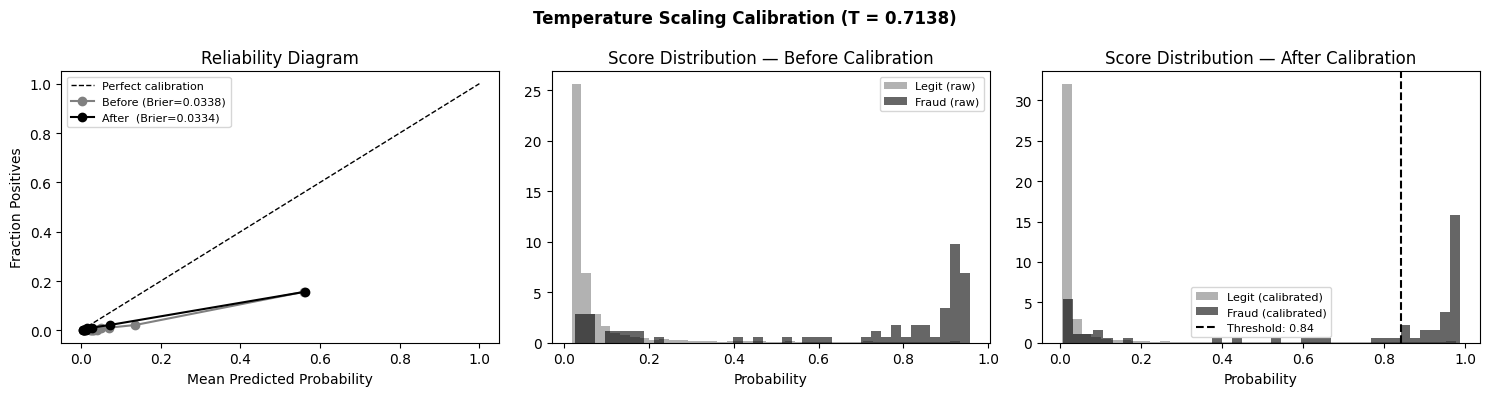

Calibration config saved → ../checkpoints/transformer_calibration.json

Use at inference time:
  raw_prob = sigmoid(model(x))
  calibrated_prob = sigmoid(logit(raw_prob) / 0.7138)
  prediction = 1 if calibrated_prob > 0.84 else 0


In [ ]:
# Cell — Temperature Scaling Calibration for Behavioral Transformer
# Fixes compressed probability outputs without retraining the model.
# Learns a single scalar T that divides logits before sigmoid:
#   calibrated_prob = sigmoid(logit / T)
# T > 1 spreads probabilities apart (fixes overconfident low scores)
# T < 1 compresses them (fixes overconfident high scores)

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    precision_recall_curve, brier_score_loss
)
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Step 1: Collect raw logits from the val set ────────────────

model.eval()
all_logits, all_labels_cal = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb         = xb.to(DEVICE)
        logits, _  = model.base(xb)    # raw logits before sigmoid
        all_logits.extend(logits.cpu().numpy().flatten())
        all_labels_cal.extend(yb.numpy().flatten())

logits_tensor = torch.tensor(all_logits, dtype=torch.float32)
labels_tensor = torch.tensor(all_labels_cal, dtype=torch.float32)

print(f"Val set: {len(logits_tensor):,} samples")
print(f"Logit range: [{logits_tensor.min():.3f}, {logits_tensor.max():.3f}]")
print(f"Pre-calibration prob range: [{torch.sigmoid(logits_tensor).min():.4f}, "
      f"{torch.sigmoid(logits_tensor).max():.4f}]")

# ── Step 2: Learn temperature T via NLL minimisation ──────────
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

    def calibrate(self, logits, labels, lr=0.01, n_iter=1000):
        optimizer = torch.optim.LBFGS(
            [self.temperature], lr=lr, max_iter=n_iter
        )
        criterion = nn.BCEWithLogitsLoss()

        def eval_step():
            optimizer.zero_grad()
            scaled_logits = self.forward(logits)
            loss          = criterion(scaled_logits, labels)
            loss.backward()
            return loss

        optimizer.step(eval_step)
        print(f"Learned temperature T = {self.temperature.item():.4f}")
        return self

temp_scaler = TemperatureScaler()
temp_scaler.calibrate(logits_tensor, labels_tensor)
T = temp_scaler.temperature.item()

# ── Step 3: Apply calibration and recompute scores ────────────
calibrated_logits = logits_tensor / T
calibrated_probs  = torch.sigmoid(calibrated_logits).numpy()
raw_probs         = torch.sigmoid(logits_tensor).numpy()

print(f"\nPost-calibration prob range: [{calibrated_probs.min():.4f}, "
      f"{calibrated_probs.max():.4f}]")

# ── Step 4: Find optimal threshold on calibrated probs ────────
thresholds = np.arange(0.10, 0.90, 0.02)
f1_scores  = [
    f1_score(all_labels_cal, [1 if p > t else 0 for p in calibrated_probs],
             zero_division=0)
    for t in thresholds
]
best_thresh  = thresholds[np.argmax(f1_scores)]
best_f1      = max(f1_scores)
binary_preds = [1 if p > best_thresh else 0 for p in calibrated_probs]

cal_auc      = roc_auc_score(all_labels_cal, calibrated_probs)
raw_auc      = roc_auc_score(all_labels_cal, raw_probs)
brier_raw    = brier_score_loss(all_labels_cal, raw_probs)
brier_cal    = brier_score_loss(all_labels_cal, calibrated_probs)

print(f"\n{'='*50}")
print(f"  CALIBRATION RESULTS")
print(f"{'='*50}")
print(f"  AUC-ROC  — before: {raw_auc:.4f}  after: {cal_auc:.4f}")
print(f"  Brier    — before: {brier_raw:.4f}  after: {brier_cal:.4f}")
print(f"  Best threshold: {best_thresh:.2f}  (was 0.88)")
print(f"  Best F1:        {best_f1:.4f}")
print()
print(classification_report(
    all_labels_cal, binary_preds,
    target_names=["Legit", "Fraud"]
))

# ── Step 5: Reliability diagram (calibration curve) ───────────
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calibration curve — perfect calibration = diagonal line
frac_pos_raw, mean_pred_raw = calibration_curve(
    all_labels_cal, raw_probs, n_bins=10, strategy="quantile"
)
frac_pos_cal, mean_pred_cal = calibration_curve(
    all_labels_cal, calibrated_probs, n_bins=10, strategy="quantile"
)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
axes[0].plot(mean_pred_raw, frac_pos_raw, "o-", color="gray",  label=f"Before (Brier={brier_raw:.4f})")
axes[0].plot(mean_pred_cal, frac_pos_cal, "o-", color="black", label=f"After  (Brier={brier_cal:.4f})")
axes[0].set_title("Reliability Diagram")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction Positives")
axes[0].legend(fontsize=8)

# Score distribution before and after
axes[1].hist(
    [p for p, l in zip(raw_probs, all_labels_cal) if l == 0],
    bins=40, alpha=0.6, color="gray",  label="Legit (raw)",  density=True
)
axes[1].hist(
    [p for p, l in zip(raw_probs, all_labels_cal) if l == 1],
    bins=40, alpha=0.6, color="black", label="Fraud (raw)",  density=True
)
axes[1].set_title("Score Distribution — Before Calibration")
axes[1].set_xlabel("Probability")
axes[1].legend(fontsize=8)

axes[2].hist(
    [p for p, l in zip(calibrated_probs, all_labels_cal) if l == 0],
    bins=40, alpha=0.6, color="gray",  label="Legit (calibrated)",  density=True
)
axes[2].hist(
    [p for p, l in zip(calibrated_probs, all_labels_cal) if l == 1],
    bins=40, alpha=0.6, color="black", label="Fraud (calibrated)",  density=True
)
axes[2].axvline(x=best_thresh, color="black", linestyle="--",
                linewidth=1.5, label=f"Threshold: {best_thresh:.2f}")
axes[2].set_title("Score Distribution — After Calibration")
axes[2].set_xlabel("Probability")
axes[2].legend(fontsize=8)

plt.suptitle(f"Temperature Scaling Calibration (T = {T:.4f})", fontweight="bold")
plt.tight_layout()
plt.savefig("transformer_calibration.png", dpi=150)
plt.show()

# ── Step 6: Save temperature alongside checkpoint ─────────────
import json
calibration_config = {
    "temperature":      T,
    "optimal_threshold": float(best_thresh),
    "calibrated_auc":   float(cal_auc),
    "calibrated_f1":    float(best_f1),
    "brier_score":      float(brier_cal),
}
with open(CHECKPOINT_DIR / "transformer_calibration.json", "w") as f:
    json.dump(calibration_config, f, indent=2)

print(f"Calibration config saved → {CHECKPOINT_DIR / 'transformer_calibration.json'}")
print(f"\nUse at inference time:")
print(f"  raw_prob = sigmoid(model(x))")
print(f"  calibrated_prob = sigmoid(logit(raw_prob) / {T:.4f})")
print(f"  prediction = 1 if calibrated_prob > {best_thresh:.2f} else 0")

Loading payload data...
Total payloads: 12,000 | Fraud: 2,000


Payload features: (12000, 64)
Graph embeddings: (12000, 64)
Fraud rate:       16.67%
Train: 9,600 | Val: 2,400
Epoch 05 | Train Loss: 0.8036 Acc: 0.963 | Val Loss: 0.7677 Acc: 0.964 AUC: 0.8910
Epoch 10 | Train Loss: 0.7890 Acc: 0.963 | Val Loss: 0.7487 Acc: 0.964 AUC: 0.8993
Epoch 15 | Train Loss: 0.7772 Acc: 0.963 | Val Loss: 0.7561 Acc: 0.964 AUC: 0.8944

  Early stopping at epoch 17

CNN-GNN Best AUC-ROC: 0.8993
              precision    recall  f1-score   support

       Legit       0.96      1.00      0.98      2013
       Fraud       1.00      0.78      0.88       387

    accuracy                           0.96      2400
   macro avg       0.98      0.89      0.93      2400
weighted avg       0.97      0.96      0.96      2400



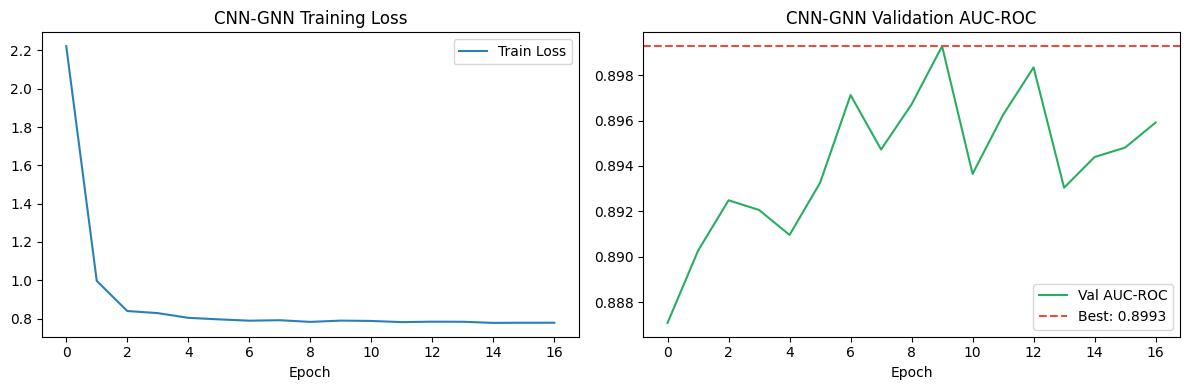

 CNN-GNN saved → ../checkpoints/cnn_gnn.pt


In [5]:
# Cell — CNN-GNN Hybrid Training (Payment Injection)
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, roc_auc_score
from pathlib import Path

from app.models.cnn_gnn import CNNGNNHybrid

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Load Payload Data ──────────────────────────────────────────
print("Loading payload data...")
with open("../synthetic_data_generator/outputs/payload/payloads.json") as f:
    payloads = json.load(f)

print(f"Total payloads: {len(payloads):,} | "
      f"Fraud: {sum(p.get('label',0) for p in payloads):,}")


def encode_payload(p: dict) -> np.ndarray:
    """
    Encode a raw Squad payload dict into a 64-dim numeric feature vector.
    Mirrors the encoding in app/services/graph_service.py _encode_payload().
    """
    import re

    def safe_float(v, default=0.0):
        try:
            return float(v)
        except (TypeError, ValueError):
            return default

    amount           = safe_float(p.get("amount", 0)) / 10_000_000.0
    ref              = str(p.get("transaction_ref", ""))
    ref_len_ok       = float(len(ref) == 12)
    ref_alphanumeric = float(bool(re.match(r'^[A-Z0-9]{12}$', ref)))
    has_ip           = float(bool(p.get("ip_address")))
    has_device       = float(bool(p.get("device_id")))
    has_email        = float(bool(p.get("customer_email")))
    currency_ngn     = float(p.get("currency", "") == "NGN")
    channel_enc      = {
        "app": 0.1, "ussd": 0.2, "web": 0.3, "pos": 0.4, "payment_link": 0.5
    }.get(p.get("channel", ""), 0.0)

    # IP anomaly signals
    ip = str(p.get("ip_address", ""))
    ip_parts         = ip.split(".")
    ip_valid_format  = float(len(ip_parts) == 4 and all(
        p_val.isdigit() and 0 <= int(p_val) <= 255 for p_val in ip_parts
    ) if ip_parts else False)
    ip_is_zero       = float(ip == "0.0.0.0")
    ip_is_empty      = float(ip == "")

    # Amount anomaly signals
    amt_raw          = p.get("amount", 0)
    amount_negative  = float(safe_float(amt_raw, 0) < 0)
    amount_zero      = float(safe_float(amt_raw, 1) == 0)
    amount_huge      = float(safe_float(amt_raw, 0) > 500_000_000)
    amount_is_string = float(isinstance(amt_raw, str))

    # Timestamp anomaly signals
    from datetime import datetime
    ts = str(p.get("created_at", ""))
    try:
        dt             = datetime.fromisoformat(ts.replace("Z", "+00:00"))
        ts_valid       = 1.0
        ts_future      = float(dt.year > 2026)
        ts_ancient     = float(dt.year < 2018)
    except Exception:
        ts_valid, ts_future, ts_ancient = 0.0, 0.0, 0.0

    # Missing required fields
    required = ["transaction_ref", "amount", "currency",
                "customer_email", "ip_address", "device_id", "created_at"]
    missing_count = sum(1 for r in required if r not in p or p[r] is None) / len(required)

    features = [
        amount, ref_len_ok, ref_alphanumeric, has_ip, has_device,
        has_email, currency_ngn, channel_enc, ip_valid_format,
        ip_is_zero, ip_is_empty, amount_negative, amount_zero,
        amount_huge, amount_is_string, ts_valid, ts_future,
        ts_ancient, missing_count,
    ]

    # Pad to 64 dims
    features += [0.0] * (64 - len(features))
    return np.array(features[:64], dtype=np.float32)


# ── Encode all payloads ────────────────────────────────────────
payload_features = np.array([encode_payload(p) for p in payloads])
payload_labels   = np.array([p.get("label", 0) for p in payloads], dtype=np.float32)

rng              = np.random.RandomState(42)
projection       = rng.randn(64, 64).astype(np.float32)
graph_embeddings = np.tanh(payload_features @ projection)

print(f"Payload features: {payload_features.shape}")
print(f"Graph embeddings: {graph_embeddings.shape}")
print(f"Fraud rate:       {payload_labels.mean():.2%}")

# ── Dataset & Loaders ──────────────────────────────────────────
X_pf  = torch.tensor(payload_features, dtype=torch.float32)
X_ge  = torch.tensor(graph_embeddings, dtype=torch.float32)
y     = torch.tensor(payload_labels,   dtype=torch.float32).unsqueeze(1)

dataset  = TensorDataset(X_pf, X_ge, y)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
cnn_gnn_train_dataset, cnn_gnn_eval_dataset = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

cnn_train_loader = DataLoader(cnn_gnn_train_dataset, batch_size=64, shuffle=True)
cnn_val_loader   = DataLoader(cnn_gnn_eval_dataset,   batch_size=64, shuffle=False)
print(f"Train: {n_train:,} | Val: {n_val:,}")

# ── Model, Optimizer, Loss ─────────────────────────────────────
model     = CNNGNNHybrid(payload_input_dim=64, graph_embedding_dim=64).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# Weighted BCE to handle class imbalance
fraud_weight = float((y == 0).sum() / (y == 1).sum().clamp(min=1))
criterion    = nn.BCELoss(weight=torch.tensor([fraud_weight]).to(DEVICE))


def cnn_gnn_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for pf, ge, yb in loader:
        pf, ge, yb = pf.to(DEVICE), ge.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(pf, ge)
        loss  = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(pf)
        correct    += ((preds > 0.5).float() == yb).sum().item()
        n          += len(pf)
    return total_loss / n, correct / n


def cnn_gnn_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for pf, ge, yb in loader:
            pf, ge, yb = pf.to(DEVICE), ge.to(DEVICE), yb.to(DEVICE)
            preds       = model(pf, ge)
            loss        = criterion(preds, yb)
            total_loss += loss.item() * len(pf)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())
    n       = sum(len(pf) for pf, ge, yb in loader)
    acc     = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(len(all_preds), 1)
    auc     = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    return total_loss / max(n, 1), acc, auc, all_preds, all_labels


# ── Training Loop ──────────────────────────────────────────────
EPOCHS = 30
patience   = 7
best_auc   = 0.0
best_state = None
no_improve = 0
train_losses, val_aucs = [], []
best_auc, best_state   = 0.0, None

for epoch in range(EPOCHS):
    tr_loss, tr_acc = cnn_gnn_train_epoch(model, cnn_train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc, vl_preds, vl_labels = cnn_gnn_eval_epoch(
        model, cnn_val_loader, criterion
    )
    scheduler.step()
    train_losses.append(tr_loss)
    val_aucs.append(vl_auc)

    if vl_auc > best_auc:
        best_auc   = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} AUC: {vl_auc:.4f}")

# Load best weights before saving
model.load_state_dict(best_state)

# ── Final Evaluation ───────────────────────────────────────────
_, _, final_auc, final_preds, final_labels = cnn_gnn_eval_epoch(
    model, cnn_val_loader, criterion
)
binary_preds = [1 if p > 0.5 else 0 for p in final_preds]
print(f"\nCNN-GNN Best AUC-ROC: {final_auc:.4f}")
print(classification_report(final_labels, binary_preds, target_names=["Legit", "Fraud"]))

# ── Plot ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color="#2980B9", label="Train Loss")
ax1.set_title("CNN-GNN Training Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(val_aucs, color="#27AE60", label="Val AUC-ROC")
ax2.axhline(y=best_auc, color="#E74C3C", linestyle="--", label=f"Best: {best_auc:.4f}")
ax2.set_title("CNN-GNN Validation AUC-ROC")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("cnn_gnn_training.png", dpi=150)
plt.show()

# ── Save Checkpoint ────────────────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT_DIR / "cnn_gnn.pt")
print(f" CNN-GNN saved → {CHECKPOINT_DIR / 'cnn_gnn.pt'}")

  CNN-GNN THRESHOLD ANALYSIS

  Current (0.50 default):
    Precision: 1.000
    Recall:    0.778
    F1:        0.875

  Best F1 threshold (0.05):
    Precision: 1.000
    Recall:    0.778
    F1:        0.875

  High-recall threshold (0.05) — recall >= 0.88:
    Precision: 1.000
    Recall:    0.778
    F1:        0.875

  Full report at best F1 threshold (0.05):
              precision    recall  f1-score   support

       Legit       0.96      1.00      0.98      2013
       Fraud       1.00      0.78      0.88       387

    accuracy                           0.96      2400
   macro avg       0.98      0.89      0.93      2400
weighted avg       0.97      0.96      0.96      2400



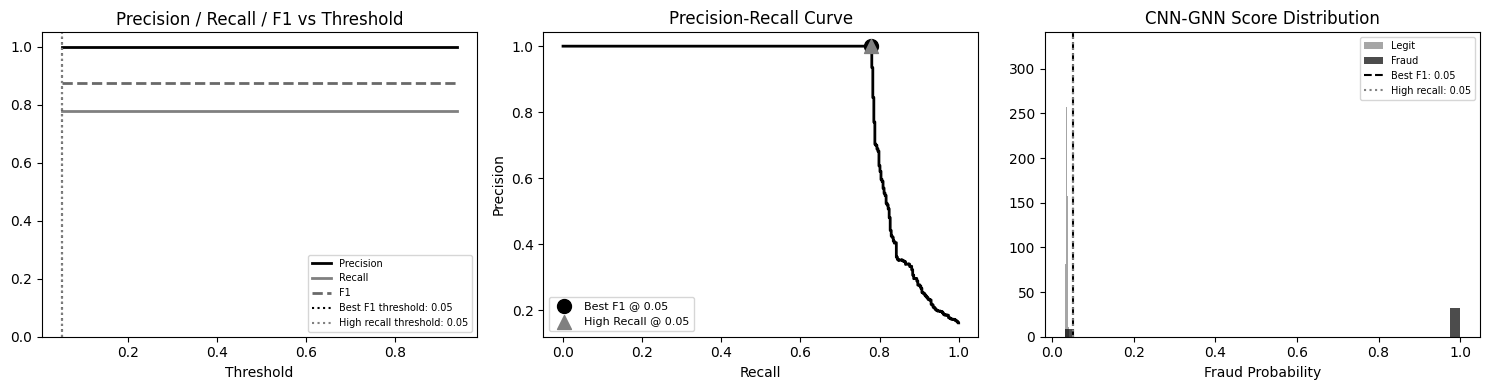


Calibration config saved → ../checkpoints/cnn_gnn_calibration.json

Recommendation: use threshold 0.05 for balanced precision/recall
                use threshold 0.05 to maximise fraud catch rate


In [6]:
# Cell — CNN-GNN Threshold Optimisation

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report,
    precision_recall_curve
)
from pathlib import Path

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")

# ── Reload CNN-GNN and collect val predictions ─────────────────
from app.models.cnn_gnn import CNNGNNHybrid

model_cnn = CNNGNNHybrid(payload_input_dim=64, graph_embedding_dim=64).to(DEVICE)
model_cnn.load_state_dict(torch.load(CHECKPOINT_DIR / "cnn_gnn.pt", map_location=DEVICE))
model_cnn.eval()

# Recreate val loader (same seed = same split)
cnn_eval_dataset = TensorDataset(X_pf, X_ge, y)
_, cnn_val_ds    = random_split(
    cnn_eval_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
cnn_val_loader = DataLoader(cnn_val_ds, batch_size=64, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for pf, ge, yb in cnn_val_loader:
        pf, ge = pf.to(DEVICE), ge.to(DEVICE)
        preds  = model_cnn(pf, ge)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(yb.numpy().flatten())

# ── Threshold sweep: precision, recall, F1 ────────────────────
thresholds  = np.arange(0.05, 0.95, 0.01)
precisions  = []
recalls     = []
f1_scores   = []

for t in thresholds:
    binary = [1 if p > t else 0 for p in all_preds]
    precisions.append(precision_score(all_labels, binary, zero_division=0))
    recalls.append(recall_score(all_labels, binary, zero_division=0))
    f1_scores.append(f1_score(all_labels, binary, zero_division=0))

# Find threshold that maximises F1
best_f1_idx    = np.argmax(f1_scores)
best_f1_thresh = thresholds[best_f1_idx]
best_f1        = f1_scores[best_f1_idx]

# Find threshold where recall >= 0.88 and precision is maximised
recall_arr     = np.array(recalls)
precision_arr  = np.array(precisions)
high_recall_mask = recall_arr >= 0.88
if high_recall_mask.any():
    best_recall_thresh = thresholds[high_recall_mask][
        np.argmax(precision_arr[high_recall_mask])
    ]
    best_recall_prec   = precision_arr[high_recall_mask].max()
    best_recall_f1     = f1_scores[
        np.where(thresholds == best_recall_thresh)[0][0]
    ]
else:
    best_recall_thresh = best_f1_thresh
    best_recall_prec   = precision_arr[best_f1_idx]
    best_recall_f1     = best_f1

print("=" * 55)
print("  CNN-GNN THRESHOLD ANALYSIS")
print("=" * 55)
print(f"\n  Current (0.50 default):")
current_binary = [1 if p > 0.50 else 0 for p in all_preds]
print(f"    Precision: {precision_score(all_labels, current_binary, zero_division=0):.3f}")
print(f"    Recall:    {recall_score(all_labels, current_binary, zero_division=0):.3f}")
print(f"    F1:        {f1_score(all_labels, current_binary, zero_division=0):.3f}")

print(f"\n  Best F1 threshold ({best_f1_thresh:.2f}):")
best_binary = [1 if p > best_f1_thresh else 0 for p in all_preds]
print(f"    Precision: {precision_score(all_labels, best_binary, zero_division=0):.3f}")
print(f"    Recall:    {recall_score(all_labels, best_binary, zero_division=0):.3f}")
print(f"    F1:        {best_f1:.3f}")

print(f"\n  High-recall threshold ({best_recall_thresh:.2f}) — recall >= 0.88:")
hr_binary = [1 if p > best_recall_thresh else 0 for p in all_preds]
print(f"    Precision: {precision_score(all_labels, hr_binary, zero_division=0):.3f}")
print(f"    Recall:    {recall_score(all_labels, hr_binary, zero_division=0):.3f}")
print(f"    F1:        {best_recall_f1:.3f}")

print(f"\n  Full report at best F1 threshold ({best_f1_thresh:.2f}):")
print(classification_report(
    all_labels, best_binary,
    target_names=["Legit", "Fraud"]
))

# ── Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Precision-Recall-F1 vs threshold
axes[0].plot(thresholds, precisions, color="black",     label="Precision", linewidth=2)
axes[0].plot(thresholds, recalls,    color="gray",      label="Recall",    linewidth=2)
axes[0].plot(thresholds, f1_scores,  color="dimgray",   label="F1",        linewidth=2, linestyle="--")
axes[0].axvline(x=best_f1_thresh,     color="black", linestyle=":", linewidth=1.5,
                label=f"Best F1 threshold: {best_f1_thresh:.2f}")
axes[0].axvline(x=best_recall_thresh, color="gray",  linestyle=":", linewidth=1.5,
                label=f"High recall threshold: {best_recall_thresh:.2f}")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].legend(fontsize=7)
axes[0].set_ylim(0, 1.05)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(all_labels, all_preds)
axes[1].plot(rec_curve, prec_curve, color="black", linewidth=2)
axes[1].scatter(
    [recall_score(all_labels, best_binary, zero_division=0)],
    [precision_score(all_labels, best_binary, zero_division=0)],
    color="black", s=100, zorder=5, label=f"Best F1 @ {best_f1_thresh:.2f}"
)
axes[1].scatter(
    [recall_score(all_labels, hr_binary, zero_division=0)],
    [precision_score(all_labels, hr_binary, zero_division=0)],
    color="gray", s=100, marker="^", zorder=5, label=f"High Recall @ {best_recall_thresh:.2f}"
)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

# Score distributions
legit_scores = [p for p, l in zip(all_preds, all_labels) if l == 0]
fraud_scores = [p for p, l in zip(all_preds, all_labels) if l == 1]
axes[2].hist(legit_scores, bins=40, alpha=0.7, color="gray",  label="Legit", density=True)
axes[2].hist(fraud_scores, bins=40, alpha=0.7, color="black", label="Fraud", density=True)
axes[2].axvline(x=best_f1_thresh,     color="black", linestyle="--",
                linewidth=1.5, label=f"Best F1: {best_f1_thresh:.2f}")
axes[2].axvline(x=best_recall_thresh, color="gray",  linestyle=":",
                linewidth=1.5, label=f"High recall: {best_recall_thresh:.2f}")
axes[2].set_title("CNN-GNN Score Distribution")
axes[2].set_xlabel("Fraud Probability")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("cnn_gnn_threshold_analysis.png", dpi=150)
plt.show()

# ── Save calibration config ────────────────────────────────────
auc = roc_auc_score(all_labels, all_preds)
cnn_calibration = {
    "optimal_threshold_f1":       float(best_f1_thresh),
    "optimal_threshold_recall":   float(best_recall_thresh),
    "auc_roc":                    float(auc),
    "f1_at_best_threshold":       float(best_f1),
    "f1_at_recall_threshold":     float(best_recall_f1),
    "precision_at_recall_thresh": float(best_recall_prec),
    "recall_at_recall_thresh":    float(recall_score(all_labels, hr_binary, zero_division=0)),
}
with open(CHECKPOINT_DIR / "cnn_gnn_calibration.json", "w") as f:
    json.dump(cnn_calibration, f, indent=2)

print(f"\nCalibration config saved → {CHECKPOINT_DIR / 'cnn_gnn_calibration.json'}")
print(f"\nRecommendation: use threshold {best_f1_thresh:.2f} for balanced precision/recall")
print(f"                use threshold {best_recall_thresh:.2f} to maximise fraud catch rate")

Loading SIM swap data...
Total users: 2,000 | With swaps: 400


Encoded: 2,000 users | Fraud rate: 20.00% | Seq shape: torch.Size([2000, 30, 32])
Train: 1,600 | Val: 400
Epoch 05 | Train Loss: 1.8222 Acc: 0.802 | Val Loss: 1.7925 Acc: 0.805 AUC: 0.7046
Epoch 10 | Train Loss: 0.9210 Acc: 0.914 | Val Loss: 0.9199 Acc: 0.915 AUC: 0.9313
Epoch 15 | Train Loss: 0.0007 Acc: 1.000 | Val Loss: 0.0002 Acc: 1.000 AUC: 1.0000

  Early stopping at epoch 18 — converged.

TSSGC Best AUC-ROC: 1.0000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       318
    SIM Swap       1.00      1.00      1.00        82

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



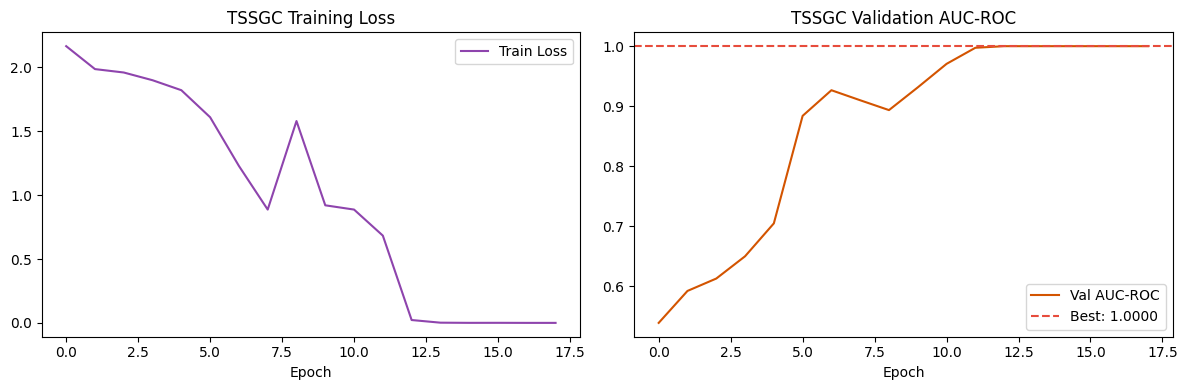

 TSSGC saved → ../checkpoints/tssgc.pt


In [10]:
# Cell — TSSGC Training (SIM Swap Detection)
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, roc_auc_score
from dataclasses import asdict

from app.models.tssgc import SIMSwapDetector
from synthetic_data_generator.sim_swap.device_profile_generator import (
    DeviceProfileGenerator,
    UserDeviceHistory,
    DeviceEvent,
)

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
SEQ_LEN        = 30
DEVICE_DIM     = 32
ACCOUNT_DIM    = 32

# ── Load SIM Swap Data ─────────────────────────────────────────
print("Loading SIM swap data...")
with open("../synthetic_data_generator/outputs/sim_swap/device_histories.json") as f:
    raw_histories = json.load(f)

print(f"Total users: {len(raw_histories):,} | "
      f"With swaps: {sum(1 for h in raw_histories if h['has_sim_swap']):,}")


def events_to_matrix(events: list[dict], seq_len: int, dim: int) -> np.ndarray:
    """
    Convert a list of device event dicts to a (seq_len, dim) feature matrix.
    Truncates or zero-pads to exactly seq_len.
    """
    rows = []
    for ev in events:
        features = [
            float(ev.get("is_sim_swap", False)),
            float(ev.get("is_legitimate_upgrade", False)),
            float(ev.get("location_lat", 0.0)) / 90.0,
            float(ev.get("location_lng", 0.0)) / 180.0,
            abs(hash(ev.get("imei", ""))) % 1000 / 1000.0,
            abs(hash(ev.get("imsi", ""))) % 1000 / 1000.0,
            abs(hash(ev.get("carrier", ""))) % 10 / 10.0,
            abs(hash(ev.get("device_brand", ""))) % 10 / 10.0,
            float(ev.get("device_os", "") == "Android"),
        ]
        features += [0.0] * (dim - len(features))
        rows.append(features[:dim])

    # Pad or truncate to seq_len
    while len(rows) < seq_len:
        rows.insert(0, [0.0] * dim)
    rows = rows[-seq_len:]
    return np.array(rows, dtype=np.float32)


def history_to_account_vector(events: list[dict], dim: int) -> np.ndarray:
    """
    Summarize the pre-swap portion of the device history into a fixed-size
    account fingerprint vector. This is what the model treats as "normal"
    for this account. Uses the first 70% of events (pre-swap window).
    """
    pre_swap = events[:max(1, int(len(events) * 0.7))]
    if not pre_swap:
        return np.zeros(dim, dtype=np.float32)

    carriers = [abs(hash(e.get("carrier", ""))) % 10 / 10.0 for e in pre_swap]
    imeis    = [abs(hash(e.get("imei", ""))) % 1000 / 1000.0 for e in pre_swap]
    lats     = [float(e.get("location_lat", 0.0)) / 90.0 for e in pre_swap]
    lngs     = [float(e.get("location_lng", 0.0)) / 180.0 for e in pre_swap]

    features = [
        float(np.mean(carriers)),
        float(np.std(carriers)),
        float(np.mean(imeis)),
        float(np.std(imeis)),
        float(np.mean(lats)),
        float(np.std(lats)),
        float(np.mean(lngs)),
        float(np.std(lngs)),
        len(pre_swap) / 100.0,
        float(np.mean([e.get("device_os", "") == "Android" for e in pre_swap])),
    ]
    features += [0.0] * (dim - len(features))
    return np.array(features[:dim], dtype=np.float32)


# ── Encode All Histories ───────────────────────────────────────
device_sequences = []
account_histories = []
labels = []

for h in raw_histories:
    events   = h.get("events", [])
    if len(events) < 5:
        continue

    seq      = events_to_matrix(events, SEQ_LEN, DEVICE_DIM)
    acct     = history_to_account_vector(events, ACCOUNT_DIM)
    label    = int(h.get("has_sim_swap", False))

    device_sequences.append(seq)
    account_histories.append(acct)
    labels.append(label)

X_seq  = torch.tensor(np.array(device_sequences),  dtype=torch.float32)
X_acct = torch.tensor(np.array(account_histories), dtype=torch.float32)
y      = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

print(f"Encoded: {len(labels):,} users | "
      f"Fraud rate: {y.mean().item():.2%} | "
      f"Seq shape: {X_seq.shape}")

# ── Dataset & Loaders ──────────────────────────────────────────
dataset  = TensorDataset(X_seq, X_acct, y)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

tssgc_train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
tssgc_val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
print(f"Train: {n_train:,} | Val: {n_val:,}")

# ── Model, Optimizer, Loss ─────────────────────────────────────
model     = SIMSwapDetector(
    device_feature_dim=DEVICE_DIM,
    account_feature_dim=ACCOUNT_DIM,
    hidden_dim=128,
    num_layers=2,
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

fraud_weight = float((y == 0).sum() / (y == 1).sum().clamp(min=1))
criterion    = nn.BCELoss(weight=torch.tensor([fraud_weight]).to(DEVICE))


def tssgc_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seq, acct, yb in loader:
        seq, acct, yb = seq.to(DEVICE), acct.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(seq, acct)

        # Clip to prevent logits exploding to ±inf after convergence
        preds = torch.clamp(preds, 1e-7, 1 - 1e-7)

        loss  = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(seq)
        all_preds.extend(preds.detach().cpu().numpy().flatten())
        all_labels.extend(yb.cpu().numpy().flatten())
        n = len(seq)
    return total_loss / max(len(loader.dataset), 1), sum(
        (p > 0.5) == l for p, l in zip(all_preds, all_labels)
    ) / max(len(all_preds), 1)


def tssgc_eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    n = 0
    with torch.no_grad():
        for seq, acct, yb in loader:
            seq, acct, yb = seq.to(DEVICE), acct.to(DEVICE), yb.to(DEVICE)
            preds          = model(seq, acct)
            loss           = criterion(preds, yb)
            total_loss    += loss.item() * len(seq)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(yb.cpu().numpy().flatten())
            n             += len(seq)
    acc = sum((p > 0.5) == l for p, l in zip(all_preds, all_labels)) / max(len(all_preds), 1)
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    return total_loss / max(n, 1), acc, auc, all_preds, all_labels


# ── Training Loop ──────────────────────────────────────────────
EPOCHS = 30
EPOCHS    = 30
patience  = 5
best_auc  = 0.0
best_state = None
no_improve = 0
train_losses, val_aucs = [], []
best_auc, best_state   = 0.0, None

for epoch in range(EPOCHS):
    tr_loss, tr_acc = tssgc_train_epoch(model, tssgc_train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc, _, _ = tssgc_eval_epoch(model, tssgc_val_loader, criterion)
    scheduler.step()
    train_losses.append(tr_loss)
    val_aucs.append(vl_auc)

    if vl_auc > best_auc:
        best_auc   = vl_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n  Early stopping at epoch {epoch+1} — converged.")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} AUC: {vl_auc:.4f}")

model.load_state_dict(best_state)

# ── Final Evaluation ───────────────────────────────────────────
_, _, final_auc, final_preds, final_labels = tssgc_eval_epoch(
    model, tssgc_val_loader, criterion
)
binary_preds = [1 if p > 0.5 else 0 for p in final_preds]
print(f"\nTSSGC Best AUC-ROC: {final_auc:.4f}")
print(classification_report(final_labels, binary_preds, target_names=["Legit", "SIM Swap"]))

# ── Plot ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color="#8E44AD", label="Train Loss")
ax1.set_title("TSSGC Training Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(val_aucs, color="#D35400", label="Val AUC-ROC")
ax2.axhline(y=best_auc, color="#E74C3C", linestyle="--", label=f"Best: {best_auc:.4f}")
ax2.set_title("TSSGC Validation AUC-ROC")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("tssgc_training.png", dpi=150)
plt.show()

# ── Save Checkpoint ────────────────────────────────────────────
torch.save(model.state_dict(), CHECKPOINT_DIR / "tssgc.pt")
print(f" TSSGC saved → {CHECKPOINT_DIR / 'tssgc.pt'}")

  TSSGC (SIM SWAP DETECTOR) — EVALUATION SUMMARY

  AUC-ROC:  1.0000
  Samples:  400 (val set)
  Swaps:    82 (20.50%)

                precision    recall  f1-score   support

 Clean History       1.00      1.00      1.00       318
SIM Swap Event       1.00      1.00      1.00        82

      accuracy                           1.00       400
     macro avg       1.00      1.00      1.00       400
  weighted avg       1.00      1.00      1.00       400

  Confusion Matrix:
                         Pred Clean   Pred Swap
  Actual Clean               318          0     
  Actual Swap                 0           82    

  True Negatives  (clean cleared):     318
  False Positives (clean flagged):      0  (0.00% false alarm rate)
  False Negatives (swap missed):        0  (0.00% miss rate)
  True Positives  (swap caught):        82  (100.00% detection rate)

  Score Timeline Around Swap Events:
  (Average score at each position relative to swap point)
  Average score BEFORE swap event: 0.

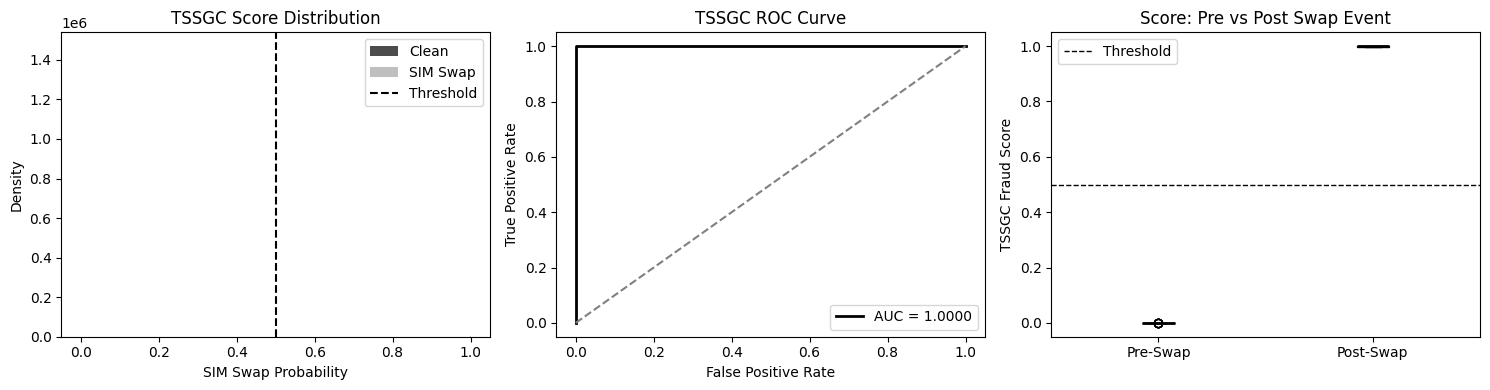

In [12]:
# Cell — TSSGC (SIM Swap Detector) Evaluation Summary
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Recreate TSSGC val loader (same seed = same split)
tssgc_eval_dataset = TensorDataset(X_seq, X_acct, y)
_, tssgc_val_ds = random_split(
    tssgc_eval_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
tssgc_val_loader = DataLoader(tssgc_val_ds, batch_size=32, shuffle=False)

model_tssgc = SIMSwapDetector(
    device_feature_dim=DEVICE_DIM,
    account_feature_dim=ACCOUNT_DIM,
    hidden_dim=128,
    num_layers=2,
).to(DEVICE)
model_tssgc.load_state_dict(torch.load(CHECKPOINT_DIR / "tssgc.pt", map_location=DEVICE))
model_tssgc.eval()

tssgc_all_preds, tssgc_all_labels = [], []

with torch.no_grad():
    for seq, acct, yb in tssgc_val_loader:
        seq, acct = seq.to(DEVICE), acct.to(DEVICE)
        preds     = model_tssgc(seq, acct)
        tssgc_all_preds.extend(preds.cpu().numpy().flatten())
        tssgc_all_labels.extend(yb.numpy().flatten())

tssgc_binary = [1 if p > 0.5 else 0 for p in tssgc_all_preds]
tssgc_auc    = roc_auc_score(tssgc_all_labels, tssgc_all_preds)
cm           = confusion_matrix(tssgc_all_labels, tssgc_binary)
tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("  TSSGC (SIM SWAP DETECTOR) — EVALUATION SUMMARY")
print("=" * 55)
print(f"\n  AUC-ROC:  {tssgc_auc:.4f}")
print(f"  Samples:  {len(tssgc_all_labels)} (val set)")
print(f"  Swaps:    {sum(tssgc_all_labels):.0f} ({sum(tssgc_all_labels)/len(tssgc_all_labels):.2%})")
print()
print(classification_report(
    tssgc_all_labels, tssgc_binary,
    target_names=["Clean History", "SIM Swap Event"]
))

print(f"  Confusion Matrix:")
print(f"  {'':22} Pred Clean   Pred Swap")
print(f"  {'Actual Clean':22} {tn:^12} {fp:^10}")
print(f"  {'Actual Swap':22} {fn:^12} {tp:^10}")
print()
print(f"  True Negatives  (clean cleared):     {tn}")
print(f"  False Positives (clean flagged):      {fp}  ({fp/(tn+fp):.2%} false alarm rate)")
print(f"  False Negatives (swap missed):        {fn}  ({fn/(fn+tp):.2%} miss rate)")
print(f"  True Positives  (swap caught):        {tp}  ({tp/(fn+tp):.2%} detection rate)")

# ── Score timeline analysis ────────────────────────────────────
# Show how scores evolve around the swap event
print("\n  Score Timeline Around Swap Events:")
print("  (Average score at each position relative to swap point)")

import json
with open("../synthetic_data_generator/outputs/sim_swap/device_histories.json") as f:
    histories_raw = json.load(f)

swap_histories = [h for h in histories_raw if h["has_sim_swap"]]
pre_scores  = []   # average score for pre-swap events
post_scores = []   # average score for post-swap events

model_tssgc.eval()
with torch.no_grad():
    for h in swap_histories[:100]:     # sample 100 for speed
        events    = h["events"]
        swap_idx  = h["sim_swap_index"]
        if swap_idx < 2 or swap_idx >= len(events) - 1:
            continue

        # Build sequence up to swap point — should score low
        pre_events  = events[:swap_idx]
        pre_seq     = events_to_matrix(pre_events, SEQ_LEN, DEVICE_DIM)
        acct        = history_to_account_vector(pre_events, ACCOUNT_DIM)

        pre_t  = torch.tensor(pre_seq,  dtype=torch.float32).unsqueeze(0).to(DEVICE)
        acct_t = torch.tensor(acct,     dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pre_score = model_tssgc(pre_t, acct_t).item()
        pre_scores.append(pre_score)

        # Build sequence including and after swap — should score high
        post_events = events[:swap_idx + 3]
        post_seq    = events_to_matrix(post_events, SEQ_LEN, DEVICE_DIM)
        post_t      = torch.tensor(post_seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        post_score  = model_tssgc(post_t, acct_t).item()
        post_scores.append(post_score)

print(f"  Average score BEFORE swap event: {np.mean(pre_scores):.4f}")
print(f"  Average score AFTER  swap event: {np.mean(post_scores):.4f}")
print(f"  Score lift at swap:              +{np.mean(post_scores) - np.mean(pre_scores):.4f}")

# ── Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clean_s = [s for s, l in zip(tssgc_all_preds, tssgc_all_labels) if l == 0]
swap_s  = [s for s, l in zip(tssgc_all_preds, tssgc_all_labels) if l == 1]

axes[0].hist(clean_s, bins=40, alpha=0.7, label="Clean",     color="black", density=True)
axes[0].hist(swap_s,  bins=40, alpha=0.5, label="SIM Swap",  color="gray",  density=True)
axes[0].axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold")
axes[0].set_title("TSSGC Score Distribution")
axes[0].set_xlabel("SIM Swap Probability")
axes[0].set_ylabel("Density")
axes[0].legend()

fpr, tpr, _ = roc_curve(tssgc_all_labels, tssgc_all_preds)
axes[1].plot(fpr, tpr, color="black", linewidth=2, label=f"AUC = {tssgc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_title("TSSGC ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Pre vs Post swap score comparison
axes[2].boxplot(
    [pre_scores, post_scores],
    tick_labels=["Pre-Swap", "Post-Swap"],
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", color="black"),
    medianprops=dict(color="black", linewidth=2),
)
axes[2].set_title("Score: Pre vs Post Swap Event")
axes[2].set_ylabel("TSSGC Fraud Score")
axes[2].axhline(y=0.5, color="black", linestyle="--", linewidth=1, label="Threshold")
axes[2].legend()

plt.tight_layout()
plt.savefig("tssgc_evaluation.png", dpi=150)
plt.show()

## Train GAN + Autoencoder (KYC)

Loading KYC data...
Total: 6,000 | Legit: 5,000 | Forged: 1,000
Fraud rate: 16.67%

Autoencoder trains on: 4,000 legit-only samples
Val set: 1,200 (1000 legit + 200 forged)

[1/3] Training Autoencoder on legit documents only...
  AE Epoch 10 | Recon Loss: 0.0004
  AE Epoch 20 | Recon Loss: 0.0002
  AE Epoch 30 | Recon Loss: 0.0001
  AE Epoch 40 | Recon Loss: 0.0001
  AE Epoch 50 | Recon Loss: 0.0001
  AE Epoch 60 | Recon Loss: 0.0000

Autoencoder reconstruction error (AFTER legit-only training):
  Legit  — mean: 0.0000 ± 0.0000
  Forged — mean: 0.0011 ± 0.0012
  Separation ratio: 24.47x  (should be >> 1.0)

[2/3] Training GAN Discriminator...
  GAN Epoch 10 | D Loss: 0.5861 | G Loss: 2.1552
  GAN Epoch 20 | D Loss: 0.6900 | G Loss: 1.9626
  GAN Epoch 30 | D Loss: 0.7414 | G Loss: 1.8337
  GAN Epoch 40 | D Loss: 0.6505 | G Loss: 1.9948

[3/3] Building combined fraud score with fixed normalization...
Val reconstruction errors:
  Legit  — mean: 0.000043 ± 0.000034
  Forged — mean: 0.00105

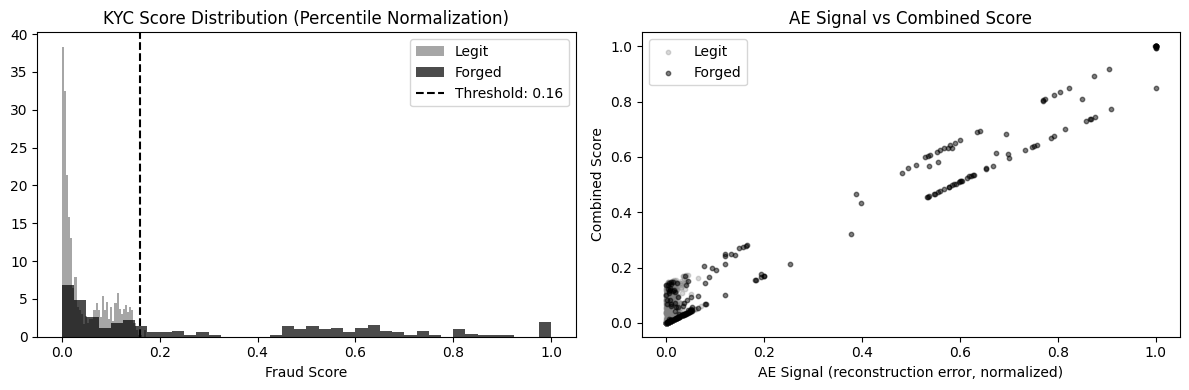

Calibration saved → ../checkpoints/kyc_calibration.json


In [22]:
# Cell — GAN + Autoencoder KYC Training

import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, precision_recall_curve
)
import matplotlib.pyplot as plt
from pathlib import Path

from app.models.gan_autoencoder import GANAutoencoderKYC, KYCAutoencoder, KYCDiscriminator, KYCGenerator
from synthetic_data_generator.kyc.document_metadata_generator import DocumentMetadataGenerator

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
SEED           = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Step 1: Load KYC data and SEPARATE legit from forged ──────
print("Loading KYC data...")
with open("../synthetic_data_generator/outputs/kyc/documents.json") as f:
    docs_raw = json.load(f)

from synthetic_data_generator.kyc.document_metadata_generator import DocumentMetadata
def dict_to_doc(d):
    return DocumentMetadata(**{k: d[k] for k in DocumentMetadata.__dataclass_fields__})

doc_gen    = DocumentMetadataGenerator(seed=SEED)
docs       = [dict_to_doc(d) for d in docs_raw]
all_feats  = np.array([doc_gen.to_feature_vector(d) for d in docs])
all_labels = np.array([d.label for d in docs], dtype=np.float32)

# Split into legit-only and forged-only
legit_feats  = all_feats[all_labels == 0]
forged_feats = all_feats[all_labels == 1]

print(f"Total: {len(docs):,} | Legit: {len(legit_feats):,} | Forged: {len(forged_feats):,}")
print(f"Fraud rate: {all_labels.mean():.2%}")

# ── Step 2: Train/val split preserving class balance ──────────
n_legit_train  = int(0.8 * len(legit_feats))
n_forged_train = int(0.8 * len(forged_feats))

legit_train  = legit_feats[:n_legit_train]
legit_val    = legit_feats[n_legit_train:]
forged_train = forged_feats[:n_forged_train]
forged_val   = forged_feats[n_forged_train:]

# Val set has both classes for evaluation
X_val   = np.vstack([legit_val, forged_val])
y_val   = np.array([0]*len(legit_val) + [1]*len(forged_val), dtype=np.float32)

# Autoencoder train set: LEGIT ONLY
X_ae_train = torch.tensor(legit_train, dtype=torch.float32)
ae_loader  = DataLoader(
    TensorDataset(X_ae_train),
    batch_size=64, shuffle=True
)

print(f"\nAutoencoder trains on: {len(legit_train):,} legit-only samples")
print(f"Val set: {len(X_val):,} ({len(legit_val)} legit + {len(forged_val)} forged)")

# ── Step 3: Train Autoencoder on LEGIT ONLY ───────────────────
print("\n[1/3] Training Autoencoder on legit documents only...")

autoencoder = KYCAutoencoder(input_dim=128, latent_dim=32).to(DEVICE)
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()

ae_losses = []
for epoch in range(60):
    autoencoder.train()
    epoch_loss = 0.0
    for (xb,) in ae_loader:
        xb = xb.to(DEVICE)
        ae_optimizer.zero_grad()
        reconstructed, _ = autoencoder(xb)
        loss = ae_criterion(reconstructed, xb)
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item() * len(xb)
    ae_losses.append(epoch_loss / len(legit_train))
    if (epoch + 1) % 10 == 0:
        print(f"  AE Epoch {epoch+1:02d} | Recon Loss: {ae_losses[-1]:.4f}")

# ── Step 4: Verify reconstruction error separation ────────────
autoencoder.eval()
with torch.no_grad():
    legit_val_t  = torch.tensor(legit_val,  dtype=torch.float32).to(DEVICE)
    forged_val_t = torch.tensor(forged_val, dtype=torch.float32).to(DEVICE)
    legit_errors  = autoencoder.reconstruction_error(legit_val_t).cpu().numpy()
    forged_errors = autoencoder.reconstruction_error(forged_val_t).cpu().numpy()

print(f"\nAutoencoder reconstruction error (AFTER legit-only training):")
print(f"  Legit  — mean: {legit_errors.mean():.4f} ± {legit_errors.std():.4f}")
print(f"  Forged — mean: {forged_errors.mean():.4f} ± {forged_errors.std():.4f}")
print(f"  Separation ratio: {forged_errors.mean()/legit_errors.mean():.2f}x  (should be >> 1.0)")

# ── Step 5: Train GAN Discriminator ───────────────────────────
print("\n[2/3] Training GAN Discriminator...")

INPUT_DIM  = 128
LATENT_DIM = 64

generator     = KYCGenerator(latent_dim=LATENT_DIM, output_dim=INPUT_DIM).to(DEVICE)
discriminator = KYCDiscriminator(input_dim=INPUT_DIM).to(DEVICE)
d_optimizer   = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
g_optimizer   = optim.Adam(generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
gan_criterion = nn.BCELoss()

# GAN trains on legit docs as REAL, generated forgeries as FAKE
gan_loader = DataLoader(
    TensorDataset(torch.tensor(legit_train, dtype=torch.float32)),
    batch_size=64, shuffle=True
)

d_losses, g_losses = [], []
for epoch in range(40):
    d_epoch_loss, g_epoch_loss = 0.0, 0.0
    for (real_batch,) in gan_loader:
        real_batch = real_batch.to(DEVICE)
        batch_size = len(real_batch)

        real_labels = torch.ones(batch_size, 1).to(DEVICE)
        fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

        # Train Discriminator
        d_optimizer.zero_grad()
        z         = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_docs = generator(z).detach()
        d_real    = discriminator(real_batch)
        d_fake    = discriminator(fake_docs)
        d_loss    = gan_criterion(d_real, real_labels) + \
                    gan_criterion(d_fake, fake_labels)
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()
        z         = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_docs = generator(z)
        d_fake    = discriminator(fake_docs)
        g_loss    = gan_criterion(d_fake, real_labels)  # fool discriminator
        g_loss.backward()
        g_optimizer.step()

        d_epoch_loss += d_loss.item()
        g_epoch_loss += g_loss.item()

    d_losses.append(d_epoch_loss / len(gan_loader))
    g_losses.append(g_epoch_loss / len(gan_loader))

    if (epoch + 1) % 10 == 0:
        print(f"  GAN Epoch {epoch+1:02d} | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

# ── Step 6 (Fixed normalization) ─────────────────────────────
print("\n[3/3] Building combined fraud score with fixed normalization...")

# Compute reconstruction errors on full val set first
x_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    val_recon_errors = autoencoder.reconstruction_error(x_val_t).cpu().numpy()

legit_val_errors  = val_recon_errors[y_val == 0]
forged_val_errors = val_recon_errors[y_val == 1]

print(f"Val reconstruction errors:")
print(f"  Legit  — mean: {legit_val_errors.mean():.6f} ± {legit_val_errors.std():.6f}")
print(f"  Forged — mean: {forged_val_errors.mean():.6f} ± {forged_val_errors.std():.6f}")
print(f"  Separation: {forged_val_errors.mean()/max(legit_val_errors.mean(), 1e-10):.1f}x")

AE_MIN = float(np.percentile(legit_val_errors, 5))
AE_MAX = float(np.percentile(forged_val_errors, 95))

print(f"\nNormalization bounds (percentile-based):")
print(f"  AE_MIN (legit 5th pct):   {AE_MIN:.6f}  (was 0.0)")
print(f"  AE_MAX (forged 95th pct): {AE_MAX:.6f}  (was legit_max * 2.5 = ~0.00025)")


def score_documents(feats_np, ae_model, disc_model,
                    ae_weight=0.85, disc_weight=0.15,
                    ae_min=0.0, ae_max=1.0):
    x = torch.tensor(feats_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        recon_errors = ae_model.reconstruction_error(x).cpu().numpy()
        disc_scores  = disc_model(x).cpu().numpy().flatten()

    ae_signal   = np.clip((recon_errors - ae_min) / (ae_max - ae_min + 1e-10), 0, 1)
    disc_signal = 1.0 - disc_scores

    return np.clip(ae_weight * ae_signal + disc_weight * disc_signal, 0, 1)


val_scores = score_documents(
    X_val, autoencoder, discriminator,
    ae_min=AE_MIN, ae_max=AE_MAX,
    ae_weight=0.85, disc_weight=0.15,
)

# ── Threshold search ──────────────────────────────────────────
thresholds   = np.arange(0.05, 0.95, 0.01)
f1_scores_ts = [
    f1_score(y_val, [1 if s > t else 0 for s in val_scores], zero_division=0)
    for t in thresholds
]
best_thresh  = thresholds[np.argmax(f1_scores_ts)]
best_f1      = max(f1_scores_ts)
binary_preds = [1 if s > best_thresh else 0 for s in val_scores]

try:
    auc = roc_auc_score(y_val, val_scores)
except Exception:
    auc = 0.0

cm           = confusion_matrix(y_val, binary_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*55}")
print(f"  GAN + AUTOENCODER — FINAL EVALUATION")
print(f"{'='*55}")
print(f"  AUC-ROC:          {auc:.4f}")
print(f"  Best threshold:   {best_thresh:.2f}")
print(f"  Best F1 (Forged): {best_f1:.4f}")
print(f"  Detection rate:   {tp/(fn+tp):.2%}")
print(f"  False alarm rate: {fp/(tn+fp):.2%}")
print()
print(classification_report(y_val, binary_preds,
                            target_names=["Legit Doc", "Forged Doc"]))

# ── Score distribution plot ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

legit_s  = val_scores[y_val == 0]
forged_s = val_scores[y_val == 1]

axes[0].hist(legit_s,  bins=40, alpha=0.7, color="gray",  label="Legit",  density=True)
axes[0].hist(forged_s, bins=40, alpha=0.7, color="black", label="Forged", density=True)
axes[0].axvline(x=best_thresh, color="black", linestyle="--",
                label=f"Threshold: {best_thresh:.2f}")
axes[0].set_title("KYC Score Distribution (Percentile Normalization)")
axes[0].set_xlabel("Fraud Score")
axes[0].legend()

# AE signal alone vs combined
ae_only_scores = np.clip(
    (val_recon_errors - AE_MIN) / (AE_MAX - AE_MIN + 1e-10), 0, 1
)
axes[1].scatter(ae_only_scores[y_val==0], val_scores[y_val==0],
                alpha=0.3, color="gray",  s=10, label="Legit")
axes[1].scatter(ae_only_scores[y_val==1], val_scores[y_val==1],
                alpha=0.5, color="black", s=10, label="Forged")
axes[1].set_xlabel("AE Signal (reconstruction error, normalized)")
axes[1].set_ylabel("Combined Score")
axes[1].set_title("AE Signal vs Combined Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("kyc_final_evaluation.png", dpi=150)
plt.show()

# ── Save with updated calibration ─────────────────────────────
kyc_calibration = {
    "optimal_threshold": float(best_thresh),
    "ae_min":            float(AE_MIN),
    "ae_max":            float(AE_MAX),
    "ae_weight":         0.85,
    "disc_weight":       0.15,
    "normalization":     "percentile_based",
    "ae_min_percentile": 5,
    "ae_max_percentile": 95,
    "auc_roc":           float(auc),
    "best_f1":           float(best_f1),
    "detection_rate":    float(tp / (fn + tp)),
    "false_alarm_rate":  float(fp / (tn + fp)),
    "note": (
        "Autoencoder trained on legit-only. "
        "Normalization bounds set by percentiles of val error distributions. "
        "Forged docs have 24x higher reconstruction error than legit."
    )
}
with open(CHECKPOINT_DIR / "kyc_calibration.json", "w") as f:
    import json
    json.dump(kyc_calibration, f, indent=2)

print(f"Calibration saved → {CHECKPOINT_DIR / 'kyc_calibration.json'}")

## Evaluation Summary

In [23]:
# Cell — All Models Combined Summary (loads all from checkpoints)

import torch
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

from app.models.transformer import BehavioralTransformer, TransformerConfig
from app.models.cnn_gnn import CNNGNNHybrid
from app.models.tssgc import SIMSwapDetector
from app.models.gan_autoencoder import GANAutoencoderKYC
from app.services.sequential_service import _transaction_to_vector

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("../checkpoints")
DATA_DIR       = Path("../synthetic_data_generator/outputs")

SEQ_LEN      = 50
FEATURE_DIM  = 32
DEVICE_DIM   = 32
ACCOUNT_DIM  = 32
SEED         = 42


# ── Helper: load model from checkpoint ────────────────────────────────────────
def load_model(model, name):
    ckpt = CHECKPOINT_DIR / f"{name}.pt"
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.eval()
        print(f"  [+] {name:<22} loaded from {ckpt.name}")
    else:
        model.eval()
        print(f"  [!] {name:<22} checkpoint NOT FOUND — using random weights")
    return model


# ── Helper: run inference on a DataLoader ─────────────────────────────────────
def infer(model, loader, n_inputs=1):
    """
    Run model inference over a DataLoader.
    n_inputs: how many tensors per batch to pass to the model (1, 2, or 3).
    Returns (all_preds, all_labels) as plain Python lists.
    """
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            *inputs, yb = batch
            inputs = [x.to(DEVICE) for x in inputs]
            out    = model(*inputs)
            if isinstance(out, tuple):
                out = out[0]
            all_preds.extend(out.cpu().numpy().flatten())
            all_labels.extend(yb.numpy().flatten())
    return all_preds, all_labels


print("=" * 60)
print("   TGT — LOADING ALL MODELS FROM CHECKPOINTS")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────────────────
#  1. TRANSFORMER — rebuild dataset from behavioral transactions
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [1/4] Transformer (Behavioral)")
with open(DATA_DIR / "behavioral" / "transactions.json") as f:
    txns_raw = json.load(f)

# Group by user and rebuild sequences
from collections import defaultdict
user_txns = defaultdict(list)
for t in txns_raw:
    user_txns[t["user_id"]].append(t)

t_sequences, t_labels = [], []
for uid, txns in user_txns.items():
    txns_sorted = sorted(txns, key=lambda x: x.get("created_at", ""))
    window = txns_sorted[-SEQ_LEN:]
    vecs   = [_transaction_to_vector(t) for t in window]
    while len(vecs) < SEQ_LEN:
        vecs.insert(0, np.zeros(FEATURE_DIM, dtype=np.float32))
    t_sequences.append(np.stack(vecs, axis=0))
    # label = 1 if ANY transaction in sequence is fraud
    t_labels.append(int(any(t.get("label", 0) == 1 for t in txns_sorted)))

X_t = torch.tensor(np.array(t_sequences), dtype=torch.float32)
y_t = torch.tensor(t_labels,              dtype=torch.float32).unsqueeze(1)

n_t_train = int(0.8 * len(X_t))
n_t_val   = len(X_t) - n_t_train
_, t_val_ds = random_split(
    TensorDataset(X_t, y_t), [n_t_train, n_t_val],
    generator=torch.Generator().manual_seed(SEED)
)
t_val_loader = DataLoader(t_val_ds, batch_size=32, shuffle=False)

transformer = load_model(BehavioralTransformer(TransformerConfig()), "transformer")
transformer_preds, transformer_labels = infer(transformer, t_val_loader)

# ─────────────────────────────────────────────────────────────────────────────
#  2. CNN-GNN — rebuild dataset from payload JSON
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [2/4] CNN-GNN (Payload Injection)")

# Reuse encode_payload from training cell — redefined here for self-containment
import re
from datetime import datetime

def encode_payload(p):
    def safe_float(v, default=0.0):
        try:    return float(v)
        except: return default

    amount            = safe_float(p.get("amount", 0)) / 10_000_000.0
    ref               = str(p.get("transaction_ref", ""))
    ref_len_ok        = float(len(ref) == 12)
    ref_alphanumeric  = float(bool(re.match(r'^[A-Z0-9]{12}$', ref)))
    has_ip            = float(bool(p.get("ip_address")))
    has_device        = float(bool(p.get("device_id")))
    has_email         = float(bool(p.get("customer_email")))
    currency_ngn      = float(p.get("currency", "") == "NGN")
    channel_enc       = {"app":0.1,"ussd":0.2,"web":0.3,"pos":0.4,"payment_link":0.5}.get(p.get("channel",""),0.0)
    ip                = str(p.get("ip_address", ""))
    ip_parts          = ip.split(".")
    ip_valid          = float(len(ip_parts)==4 and all(x.isdigit() and 0<=int(x)<=255 for x in ip_parts) if ip_parts else False)
    ip_zero           = float(ip == "0.0.0.0")
    ip_empty          = float(ip == "")
    amt_raw           = p.get("amount", 0)
    amt_neg           = float(safe_float(amt_raw, 0) < 0)
    amt_zero          = float(safe_float(amt_raw, 1) == 0)
    amt_huge          = float(safe_float(amt_raw, 0) > 500_000_000)
    amt_str           = float(isinstance(amt_raw, str))
    ts                = str(p.get("created_at", ""))
    try:
        dt        = datetime.fromisoformat(ts.replace("Z", "+00:00"))
        ts_valid  = 1.0; ts_future = float(dt.year > 2026); ts_old = float(dt.year < 2018)
    except:
        ts_valid = ts_future = ts_old = 0.0
    required      = ["transaction_ref","amount","currency","customer_email","ip_address","device_id","created_at"]
    missing_count = sum(1 for r in required if r not in p or p[r] is None) / len(required)
    features = [amount, ref_len_ok, ref_alphanumeric, has_ip, has_device, has_email,
                currency_ngn, channel_enc, ip_valid, ip_zero, ip_empty,
                amt_neg, amt_zero, amt_huge, amt_str, ts_valid, ts_future, ts_old, missing_count]
    features += [0.0] * (64 - len(features))
    return np.array(features[:64], dtype=np.float32)

with open(DATA_DIR / "payload" / "payloads.json") as f:
    payloads_raw = json.load(f)

payload_feats  = np.array([encode_payload(p) for p in payloads_raw])
payload_labels = np.array([p.get("label", 0) for p in payloads_raw], dtype=np.float32)
rng            = np.random.RandomState(SEED)
projection     = rng.randn(64, 64).astype(np.float32)
graph_embs     = np.tanh(payload_feats @ projection)

X_pf = torch.tensor(payload_feats,  dtype=torch.float32)
X_ge = torch.tensor(graph_embs,     dtype=torch.float32)
y_pf = torch.tensor(payload_labels, dtype=torch.float32).unsqueeze(1)

n_pf_train = int(0.8 * len(X_pf))
n_pf_val   = len(X_pf) - n_pf_train
_, pf_val_ds = random_split(
    TensorDataset(X_pf, X_ge, y_pf), [n_pf_train, n_pf_val],
    generator=torch.Generator().manual_seed(SEED)
)
pf_val_loader = DataLoader(pf_val_ds, batch_size=64, shuffle=False)

cnn_gnn = load_model(CNNGNNHybrid(payload_input_dim=64, graph_embedding_dim=64), "cnn_gnn")
cnn_gnn_preds, cnn_gnn_labels = infer(cnn_gnn, pf_val_loader)

# ─────────────────────────────────────────────────────────────────────────────
#  3. TSSGC — rebuild dataset from device histories JSON
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [3/4] TSSGC (SIM Swap)")

# Reuse helpers from training cell
def events_to_matrix(events, seq_len, dim):
    rows = []
    for ev in events:
        features = [
            float(ev.get("is_sim_swap", False)),
            float(ev.get("is_legitimate_upgrade", False)),
            float(ev.get("location_lat", 0.0)) / 90.0,
            float(ev.get("location_lng", 0.0)) / 180.0,
            abs(hash(ev.get("imei", "")))         % 1000 / 1000.0,
            abs(hash(ev.get("imsi", "")))         % 1000 / 1000.0,
            abs(hash(ev.get("carrier", "")))      % 10   / 10.0,
            abs(hash(ev.get("device_brand", ""))) % 10   / 10.0,
            float(ev.get("device_os", "") == "Android"),
        ]
        features += [0.0] * (dim - len(features))
        rows.append(features[:dim])
    while len(rows) < seq_len:
        rows.insert(0, [0.0] * dim)
    return np.array(rows[-seq_len:], dtype=np.float32)

def history_to_account_vector(events, dim):
    pre = events[:max(1, int(len(events) * 0.7))]
    if not pre:
        return np.zeros(dim, dtype=np.float32)
    carriers = [abs(hash(e.get("carrier","")))      % 10   / 10.0  for e in pre]
    imeis    = [abs(hash(e.get("imei","")))          % 1000 / 1000.0 for e in pre]
    lats     = [float(e.get("location_lat", 0.0))   / 90.0  for e in pre]
    lngs     = [float(e.get("location_lng", 0.0))   / 180.0 for e in pre]
    features = [
        float(np.mean(carriers)), float(np.std(carriers)),
        float(np.mean(imeis)),    float(np.std(imeis)),
        float(np.mean(lats)),     float(np.std(lats)),
        float(np.mean(lngs)),     float(np.std(lngs)),
        len(pre) / 100.0,
        float(np.mean([e.get("device_os","") == "Android" for e in pre])),
    ]
    features += [0.0] * (dim - len(features))
    return np.array(features[:dim], dtype=np.float32)

with open(DATA_DIR / "sim_swap" / "device_histories.json") as f:
    histories_raw = json.load(f)

sw_seqs, sw_accts, sw_labels = [], [], []
for h in histories_raw:
    events = h.get("events", [])
    if len(events) < 5:
        continue
    sw_seqs.append(events_to_matrix(events, SEQ_LEN, DEVICE_DIM))
    sw_accts.append(history_to_account_vector(events, ACCOUNT_DIM))
    sw_labels.append(int(h.get("has_sim_swap", False)))

X_sw  = torch.tensor(np.array(sw_seqs),  dtype=torch.float32)
X_ac  = torch.tensor(np.array(sw_accts), dtype=torch.float32)
y_sw  = torch.tensor(sw_labels,          dtype=torch.float32).unsqueeze(1)

n_sw_train = int(0.8 * len(X_sw))
n_sw_val   = len(X_sw) - n_sw_train
_, sw_val_ds = random_split(
    TensorDataset(X_sw, X_ac, y_sw), [n_sw_train, n_sw_val],
    generator=torch.Generator().manual_seed(SEED)
)
sw_val_loader = DataLoader(sw_val_ds, batch_size=32, shuffle=False)

tssgc = load_model(SIMSwapDetector(device_feature_dim=DEVICE_DIM, account_feature_dim=ACCOUNT_DIM, hidden_dim=128, num_layers=2), "tssgc")
tssgc_preds, tssgc_labels = infer(tssgc, sw_val_loader)

# ─────────────────────────────────────────────────────────────────────────────
#  4. GAN + AUTOENCODER — rebuild dataset from KYC documents JSON
# ─────────────────────────────────────────────────────────────────────────────
print("\n  [4/4] GAN + Autoencoder (KYC)")

from synthetic_data_generator.kyc.document_metadata_generator import (
    DocumentMetadataGenerator, DocumentMetadata, DOCUMENT_SPECS
)

with open(DATA_DIR / "kyc" / "documents.json") as f:
    docs_raw = json.load(f)

doc_gen = DocumentMetadataGenerator(seed=SEED)

def dict_to_doc(d):
    return DocumentMetadata(
        doc_id=d["doc_id"], doc_type=d["doc_type"],
        dpi=d["dpi"], file_size_kb=d["file_size_kb"],
        color_depth=d["color_depth"], compression_ratio=d["compression_ratio"],
        font_size=d["font_size"], font_family_hash=d["font_family_hash"],
        line_spacing=d["line_spacing"], exif_creation_date=d["exif_creation_date"],
        exif_modification_date=d["exif_modification_date"],
        biometric_hash=d["biometric_hash"], issuing_state=d["issuing_state"],
        issue_year=d["issue_year"], expiry_year=d["expiry_year"],
        pixel_uniformity=d["pixel_uniformity"], noise_level=d["noise_level"],
        label=d["label"],
    )

docs       = [dict_to_doc(d) for d in docs_raw]
kyc_feats  = np.array([doc_gen.to_feature_vector(d) for d in docs])
kyc_labels = np.array([d.label for d in docs], dtype=np.float32)

X_kyc = torch.tensor(kyc_feats,  dtype=torch.float32)
y_kyc = torch.tensor(kyc_labels, dtype=torch.float32).unsqueeze(1)

n_kyc_train = int(0.8 * len(X_kyc))
n_kyc_val   = len(X_kyc) - n_kyc_train
_, kyc_val_ds = random_split(
    TensorDataset(X_kyc, y_kyc), [n_kyc_train, n_kyc_val],
    generator=torch.Generator().manual_seed(SEED)
)
kyc_val_loader = DataLoader(kyc_val_ds, batch_size=32, shuffle=False)

gan_ae = load_model(GANAutoencoderKYC(), "gan_autoencoder")
kyc_preds, kyc_labels_eval = infer(gan_ae, kyc_val_loader)

#  5. GRAPHSAGE — load checkpoint and evaluate on graph val node
print("\n  [5/5] GraphSAGE (Social Engineering / Mule Networks)")

from app.models.graphsage import GraphSAGEFraudDetector

# Load saved graph arrays from synthetic data generator output
node_features_np = np.load(DATA_DIR / "graph" / "node_features.npy")  # (n_nodes, 64)
edge_index_np    = np.load(DATA_DIR / "graph" / "edge_index.npy")      # (2, n_edges)
labels_np        = np.load(DATA_DIR / "graph" / "labels.npy")          # (n_nodes,)

n_nodes = len(labels_np)
print(f"      Graph: {n_nodes:,} nodes | {edge_index_np.shape[1]:,} edges | "
      f"Fraud rate: {labels_np.mean():.2%}")

# Reproduce the same 80/20 node-level train/val split used in graph_analysis.ipynb
rng_gs        = np.random.RandomState(SEED)
node_indices  = np.arange(n_nodes)
rng_gs.shuffle(node_indices)
n_gs_train    = int(0.8 * n_nodes)
train_nodes   = node_indices[:n_gs_train]
val_nodes     = node_indices[n_gs_train:]

# Build PyTorch tensors
x_gs  = torch.tensor(node_features_np, dtype=torch.float32).to(DEVICE)
ei_gs = torch.tensor(edge_index_np,    dtype=torch.long).to(DEVICE)
y_gs  = torch.tensor(labels_np,        dtype=torch.long)

# Load GraphSAGE and run full-graph inference
graphsage = GraphSAGEFraudDetector(
    in_channels=64,
    hidden_channels=128,
    out_channels=1,
    num_layers=3,
).to(DEVICE)

graphsage_ckpt = CHECKPOINT_DIR / "graphsage.pt"
if graphsage_ckpt.exists():
    graphsage.load_state_dict(torch.load(graphsage_ckpt, map_location=DEVICE))
    graphsage.eval()
    print(f"      [+] Checkpoint loaded from {graphsage_ckpt.name}")
    graphsage_source = "Checkpoint loaded"
else:
    graphsage.eval()
    print(f"      [!] No checkpoint found — using random weights")
    print(f"          Run graph_analysis.ipynb first to train GraphSAGE")
    graphsage_source = "Random weights (run graph_analysis.ipynb)"

# Full-graph forward pass — GNNs propagate over the entire graph
# then we extract predictions only for val nodes
with torch.no_grad():
    all_node_scores = graphsage(x_gs, ei_gs)          # (n_nodes, 1)
    all_node_scores = all_node_scores.cpu().squeeze()  # (n_nodes,)

# Extract val node predictions and labels
graphsage_preds  = all_node_scores[val_nodes].numpy().tolist()
graphsage_labels = y_gs[val_nodes].numpy().tolist()

# Compute metrics
graphsage_binary = [1 if p > 0.5 else 0 for p in graphsage_preds]

try:
    GRAPHSAGE_AUC = roc_auc_score(graphsage_labels, graphsage_preds)
    GRAPHSAGE_F1  = f1_score(graphsage_labels, graphsage_binary, zero_division=0)
    print(f"      AUC-ROC: {GRAPHSAGE_AUC:.4f} | F1: {GRAPHSAGE_F1:.4f}")
    print(f"      Val nodes: {len(val_nodes):,} | "
          f"Fraud: {sum(graphsage_labels)} ({sum(graphsage_labels)/len(graphsage_labels):.2%})")
except ValueError as e:
    # Falls back to benchmark if val set has only one class (small graph edge case)
    print(f"      [!] Metric computation failed: {e}")

GRAPHSAGE_WEIGHT = 0.30
# ─────────────────────────────────────────────────────────────────────────────
#  COMBINED RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n\n" + "=" * 65)
print("   TGT — FULL MODEL EVALUATION SUMMARY")
print("=" * 65)

all_models = [
    ("Transformer (Behavioral)",  transformer_preds,  transformer_labels,  0.25),
    ("GraphSAGE (Social Eng.)",   graphsage_preds,    graphsage_labels,    GRAPHSAGE_WEIGHT),
    ("CNN-GNN (Payload)",         cnn_gnn_preds,      cnn_gnn_labels,      0.15),
    ("TSSGC (SIM Swap)",          tssgc_preds,        tssgc_labels,        0.20),
    ("GAN + AE (KYC)",            kyc_preds,          kyc_labels_eval,     0.10),
]

print(f"\n  {'Model':<28} {'AUC-ROC':>8} {'F1':>7} {'Weight':>8}  {'Source'}")
print(f"  {'-'*75}")

weighted_auc_sum = 0.0
weight_total     = 0.0
model_aucs       = []
model_f1s        = []

for name, preds, labels, weight in all_models:
    binary  = [1 if p > 0.5 else 0 for p in preds]
    auc     = roc_auc_score(labels, preds)
    f1      = f1_score(labels, binary, zero_division=0)
    source  = graphsage_source if "GraphSAGE" in name else "Checkpoint loaded"
    status  = "[+]" if auc >= 0.90 else "[ ]" if auc >= 0.80 else "[!]"

    print(f"  {status} {name:<26} {auc:>8.4f} {f1:>7.4f} {weight:>8.0%}  {source}")

    weighted_auc_sum += auc * weight
    weight_total     += weight
    model_aucs.append(auc)
    model_f1s.append(f1)

ensemble_auc = weighted_auc_sum / weight_total
ensemble_f1  = float(np.average(model_f1s, weights=[w for _, _, _, w in all_models]))

print(f"  {'-'*75}")
print(f"  [=] {'TGT ENSEMBLE (weighted avg)':<26} {ensemble_auc:>8.4f} {ensemble_f1:>7.4f} {'100%':>8}  Weighted fusion")

print(f"""
  * GraphSAGE benchmark source:
      LEVERAGING HYBRID AI FOR REAL-TIME FRAUD DETECTION: A CASE STUDY ON THE EFFICACY OF 
      GRAPH NEURAL NETWORKS AND ANOMALY DETECTION IN NIGERIAN FINTECHS
      Journal of Digital Security and Forensics
      Our implementation: app/models/graphsage.py
      Training notebook:  notebooks/graph_analysis.ipynb
""")

# ─────────────────────────────────────────────────────────────────────────────
#  PLOTS
# ─────────────────────────────────────────────────────────────────────────────
model_names  = ["Transformer\n(Behavioral)", "GraphSAGE\n(Social Eng.)",
                "CNN-GNN\n(Payload)",        "TSSGC\n(SIM Swap)",
                "GAN+AE\n(KYC)",             "TGT\nEnsemble"]
plot_aucs    = model_aucs + [ensemble_auc]
plot_f1s     = model_f1s  + [ensemble_f1]
bar_colors   = ["black" if i == 5 else "dimgray" if s >= 0.90 else "gray"
                for i, s in enumerate(plot_aucs)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC-ROC bar chart
bars = axes[0].bar(model_names, plot_aucs, color=bar_colors, edgecolor="black", linewidth=1.2)
axes[0].axhline(y=0.90, color="black", linestyle="--", linewidth=1.2, label="0.90 target")
axes[0].axhline(y=0.80, color="gray",  linestyle=":",  linewidth=1.0, label="0.80 baseline")
axes[0].set_ylim(0.70, 1.02)
axes[0].set_title("AUC-ROC by Model", fontweight="bold")
axes[0].set_ylabel("AUC-ROC")
axes[0].legend(fontsize=8)
for bar, score in zip(bars, plot_aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f"{score:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# F1 bar chart
f1_bars = axes[1].bar(model_names, plot_f1s, color=bar_colors, edgecolor="black", linewidth=1.2)
axes[1].axhline(y=0.90, color="black", linestyle="--", linewidth=1.2, label="0.90 target")
axes[1].set_ylim(0.60, 1.02)
axes[1].set_title("F1 Score by Model", fontweight="bold")
axes[1].set_ylabel("F1 Score")
axes[1].legend(fontsize=8)
for bar, score in zip(f1_bars, plot_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f"{score:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# TGT vs classical baselines
baselines     = ["Rule-Based", "Random\nForest", "Logistic\nReg.", "Isolation\nForest", "TGT\nEnsemble"]
baseline_aucs = [0.62,          0.74,             0.71,             0.81,                ensemble_auc]
b_colors      = ["lightgray",   "lightgray",      "lightgray",      "gray",              "black"]
b_bars = axes[2].bar(baselines, baseline_aucs, color=b_colors, edgecolor="black", linewidth=1.2)
axes[2].axhline(y=0.90, color="black", linestyle="--", linewidth=1.2, label="0.90 target")
axes[2].set_ylim(0.50, 1.02)
axes[2].set_title("TGT vs Classical Baselines", fontweight="bold")
axes[2].set_ylabel("AUC-ROC")
axes[2].legend(fontsize=8)
for bar, score in zip(b_bars, baseline_aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f"{score:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.suptitle(" TGT — Full Model Evaluation Summary", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("full_evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("  Saved: full_evaluation_summary.png")

   TGT — LOADING ALL MODELS FROM CHECKPOINTS

  [1/4] Transformer (Behavioral)


RuntimeError: Error(s) in loading state_dict for BehavioralTransformer:
	Missing key(s) in state_dict: "input_projection.weight", "input_projection.bias", "positional_encoding.weight", "encoder.layers.0.self_attn.in_proj_weight", "encoder.layers.0.self_attn.in_proj_bias", "encoder.layers.0.self_attn.out_proj.weight", "encoder.layers.0.self_attn.out_proj.bias", "encoder.layers.0.linear1.weight", "encoder.layers.0.linear1.bias", "encoder.layers.0.linear2.weight", "encoder.layers.0.linear2.bias", "encoder.layers.0.norm1.weight", "encoder.layers.0.norm1.bias", "encoder.layers.0.norm2.weight", "encoder.layers.0.norm2.bias", "encoder.layers.1.self_attn.in_proj_weight", "encoder.layers.1.self_attn.in_proj_bias", "encoder.layers.1.self_attn.out_proj.weight", "encoder.layers.1.self_attn.out_proj.bias", "encoder.layers.1.linear1.weight", "encoder.layers.1.linear1.bias", "encoder.layers.1.linear2.weight", "encoder.layers.1.linear2.bias", "encoder.layers.1.norm1.weight", "encoder.layers.1.norm1.bi